**All Imports **

In [ ]:
import os
from dotenv import load_dotenv
from typing import TypedDict, List
from langchain_openai import ChatOpenAI
from langchain.prompts import PromptTemplate
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, END
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

**API Keys and LLM Initialization**

In [22]:
load_dotenv(dotenv_path="openrouterapi.env")

openai_api_key = os.getenv("OPENAI_API_KEY")
print("Api has been read!")
print("Done. ")

Api has been read!
Done. 


In [23]:
llm = ChatOpenAI(
    model="z-ai/glm-4.5-air:free", 
    openai_api_base="https://openrouter.ai/api/v1",
    openai_api_key=openai_api_key,
    temperature=0.5
)

In [24]:
persist_directory = 'chroma_db_persistent'

code_samples = """
# Example 1: Function to add two numbers
def add(a, b):
    \"\"\"This function adds two numbers.\"\"\"
    return a + b

# Example 2: Simple for loop
for i in range(5):
    print(f"Loop iteration {i}")

# Example 3: List comprehension
squares = [x**2 for x in range(10)]
print(squares)
"""
with open("code_examples.txt", "w") as f:
    f.write(code_samples)


loader = TextLoader("code_examples.txt")
documents = loader.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=250, chunk_overlap=50)
docs = text_splitter.split_documents(documents)
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectordb = Chroma.from_documents(
    documents=docs, 
    embedding=embedding_model,
    persist_directory=persist_directory
)
retriever = vectordb.as_retriever()
print("RAG retriever is now ready.")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


RAG retriever is now ready.


**Graph State and Nodes**

In [25]:
class AgentState(TypedDict):
    messages: List[BaseMessage]
    intent: str
    retrevContent: List[str]

def intenClassifier(state: AgentState):
    """Classifies the user intent to route the request correctly. """
    latestMessage = state['messages'][-1].content.lower()

    if "generate" in latestMessage or "write" in latestMessage or "create" in latestMessage:
        intent = "generate"
    elif "explain" in latestMessage or "what is" in latestMessage or "describe" in latestMessage:
        intent = "explain"
    else:
        intent = "clarify"

    print(f"The intent of the user has been classified as: {intent}. ")

    return {"intent": intent}


def retrieveExamples(state:AgentState):
    """Retrieving relevant code examples using the RAG system. """
    lastMessage = state["messages"][-1].content
    retrievedDocs = retriever.invoke(lastMessage)
    contextSnipp = [doc.page_content for doc in retrievedDocs]
    print(f"Retrieved {len(contextSnipp)} context")
    return {"retrieval_context": contextSnipp}

def LLM(state:AgentState):
    """Calling the LLM with the prompt from the user to know their intent. """

    intent = state["intent"]
    context = state.get("retrevContent", [])
    user_input = state['messages']

    if intent == "generate":
        template = """You are a Python code assistant. Based on the following examples, generate the Python code requested by the user.

        Examples:
        {context}

        User Request:
        {input}"""
        prompt = PromptTemplate.from_template(template).format(context="\\n---\\n".join(context), input=user_input)

    elif intent == "explain":
        template = "Explain the following Python concept like I am 5: {input}"
        prompt = PromptTemplate.from_template(template).format(input=user_input)


    else: #clarify
        prompt = "I'm not sure how to help with that. Please specify if you want me to 'generate' or 'explain' Python code."  

    response = llm.invoke(prompt)
    return {'messages': state["messages"] + [AIMessage(content=response.content)]}


Done. 


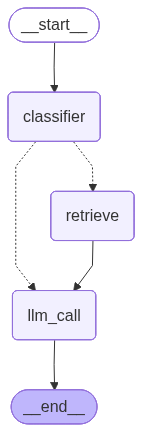

In [26]:
def router(state:AgentState):
    """Determines the next step based on the intent. """
    if state['intent'] == "generate":
        return "retrieve"
    else:
        return "llm_call";

graph = StateGraph(AgentState)
graph.add_node("classifier", intenClassifier)
graph.add_node("retrieve", retrieveExamples)
graph.add_node("llm_call", LLM)

graph.set_entry_point("classifier")

graph.add_conditional_edges(
    "classifier",
    router,
    {
        "retrieve": "retrieve", 
        "llm_call": "llm_call"
    }
)

graph.add_edge("retrieve", "llm_call")
graph.add_edge("llm_call", END)

app = graph.compile()

print("Done. ")


#drawing the Nodes and edges

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

**the Assistant**

In [ ]:
print("The LangGraph Python Assistant is running. Type 'quit' to exit.")


while True:
    user_input = input("User: ")
    if user_input == "quit" or user_input == "Quit":
        print("The Assistant has been terminated. ")
        break
    
    inputs = {"messages": [HumanMessage(content=user_input)]}
    finalState = app.invoke(inputs)
    print("AI: ", finalState['messages'][-1].content)

The LangGraph Python Assistant is running. Type 'quit' to exit.
The intent of the user has been classified as: explain. 
AI:  ### Explanation for a 5-Year-Old:

Imagine you have a magic robot friend 🤖. When you say `print(1+1)` to it, here’s what happens:

1. **`1+1`**  
   Think of this like your fingers: hold up **1 finger** on your left hand, then **1 finger** on your right hand. How many fingers do you see? **Two!**  
   So `1+1` is just a math way of saying **"two"**.

2. **`print(...)`**  
   This is like telling your robot:  
   *"Hey robot, show me what’s inside the parentheses!"*  
   It’s like when you hold up your two fingers and shout, **"Look! Two!"**

3. **Putting It Together: `print(1+1)`**  
   You’re saying:  
   *"Robot, show me the answer to 1+1!"*  
   So the robot writes **`2`** on the screen.  

---

### What Happens When You Run It?  
When you type `print(1+1)` in Python and press Enter, the computer does the math (1+1 = 2) and prints:  
```
2
```

🎉 **Just like 